# **합성함수**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class Composite:
    def __init__(self, func, name="f"):
        self.func = func
        self.name = name

    def __call__(self, x):
        return self.func(x)

    # >> 연산자를 사용하여 f >> g 형태로 합성 (f(g(x)))
    def __rshift__(self, other):
        combined_func = lambda x: self.func(other.func(x))
        new_name = f"{self.name}({other.name}(x))"
        return Composite(combined_func, new_name)

# 1. 기본 함수를 객체로 감싸기
f = Composite(np.sin, "sin")
g = Composite(lambda x: x**2, "x²")

h = f >> g

# 3. 데이터 생성
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)
y = h(x)

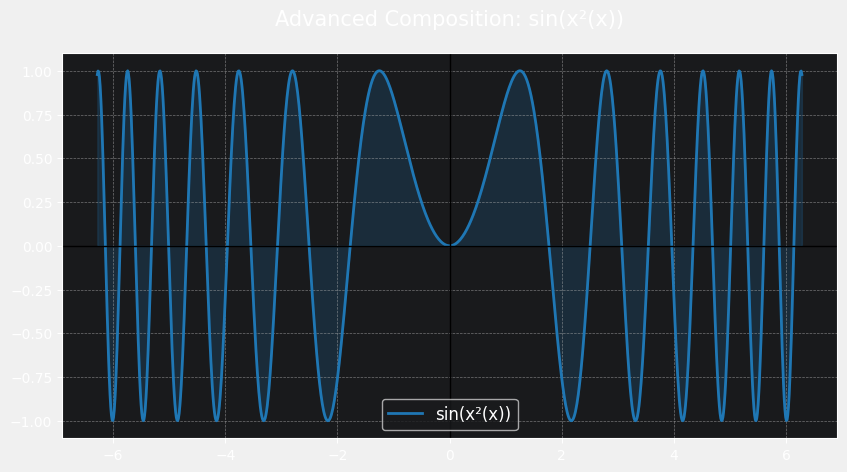

In [3]:
plt.figure(figsize=(10, 5), facecolor='#f0f0f0')
plt.plot(x, y, label=h.name, color='#1f77b4', linewidth=2)
plt.fill_between(x, y, alpha=0.2, color='#1f77b4')

plt.title(f"Advanced Composition: {h.name}", fontsize=15, pad=20)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.show()